# 061 — Round 4: grouped k-fold evaluation

Reads whatever `060_kfold_training.ipynb` has produced under `models/kfold/fold_*/`
and reports:

- **§2 — per-fold held-out pixel metrics** (`mae`/`psnr`/`ssim` on that fold's
  held-out real artworks, scored by that fold's own model) → **mean ± std** across
  folds. This is the variance estimate `fixing.md` #4 is about.
- **§3 — detection on `GT01`-`GT03`**: `structural delta` and `structural z` AUROC +
  stroke coherence, **per fold-model** and for the **3-fold ensemble** (mean of the
  fold `μ`s). The GT paintings are external to every fold, so each fold-model is a
  genuine held-out predictor for them.
- **§4 — headline** numbers for the write-up.

Runs with **≥ 1 fold**; with `< K` folds the mean±std is over what exists, with a
warning. Re-run as more folds finish.

Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports — the `C4`/`C5` detection toolkit plus the k-fold split.

In [2]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.calibration import laplace_sigma_from_scale, learned_zscore, structural_zscore
from scripts.config import settings
from scripts.dataset import build_dataset, load_image_pairs, pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.detection import evaluate_detection
from scripts.kfold import fold_artwork_groups, grouped_kfold_splits
from scripts.stroke_stats import stroke_coherence
from scripts.trainer_nll import load_model_nll
from scripts.visualization import plot_gt_signal_gallery

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Which folds are available

In [3]:
ARCH = "attention_unet_nll"
K = settings.KFOLD_K
KFOLD_DIR = settings.MODELS_DIR / "kfold"

pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
held_out = fold_artwork_groups(pairs, k=K, seed=settings.KFOLD_SEED)
splits = grouped_kfold_splits(pairs, k=K, seed=settings.KFOLD_SEED)

available = [
    f for f in range(K)
    if (KFOLD_DIR / f"fold_{f}" / ARCH / "best_model.keras").exists()
]
print(f"folds trained: {available}  ({len(available)}/{K})")
if not available:
    raise RuntimeError("No fold checkpoints under models/kfold/ — run 060 first.")
if len(available) < K:
    print(f"WARNING: {K - len(available)} fold(s) missing — statistics are over "
          f"{len(available)} fold(s) only. Re-run when more finish.")

folds trained: [0, 1, 2]  (3/3)


## 2. Per-fold held-out pixel metrics

Each fold's model evaluated on its own held-out real artworks (full-resolution,
`batch_size=1`). The spread across folds is the point of the round.

In [4]:
pixel_rows = {}
for fold in available:
    model = load_model_nll(
        ARCH, model_dir=KFOLD_DIR / f"fold_{fold}",
        loss_name="laplace_nll", beta=settings.NLL_BETA,
    )
    _, val_pairs = splits[fold]
    val_ds = build_dataset(val_pairs, batch_size=1, augment=False, shuffle=False)
    scores = dict(zip(model.metrics_names, model.evaluate(val_ds, verbose=0)))
    pixel_rows[fold] = scores
    print(f"fold {fold}: " + "  ".join(f"{k}={v:.4f}" for k, v in scores.items()))
    del model, val_ds
    gc.collect()
    tf.keras.backend.clear_session()

keys = [k for k in ("loss", "mae", "psnr", "ssim") if k in next(iter(pixel_rows.values()))]
print(f"\n{'metric':<10}" + "".join(f"fold {f}".rjust(12) for f in available) + f"{'mean':>12}{'std':>10}")
print("-" * (10 + 12 * len(available) + 22))
for k in keys:
    vals = np.array([pixel_rows[f][k] for f in available])
    print(f"{k:<10}" + "".join(f"{pixel_rows[f][k]:.4f}".rjust(12) for f in available)
          + f"{vals.mean():>12.4f}{vals.std():>10.4f}")

2026-08-27 22:57:33.300511: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-27 22:57:33.300532: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-27 22:57:33.300536: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-27 22:57:33.300548: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 22:57:33.300557: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-08-27 22:57:34.247317: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


fold 0: loss=-0.3844  compile_metrics=0.1283
fold 1: loss=-0.4451  compile_metrics=0.0983
fold 2: loss=-0.4424  compile_metrics=0.1040

metric          fold 0      fold 1      fold 2        mean       std
--------------------------------------------------------------------
loss           -0.3844     -0.4451     -0.4424     -0.4240    0.0280


## 3. Detection on the GT paintings

`GT01`/`GT02`/`GT03` are outside every fold, so each fold-model is a held-out
predictor for them. Signals: `structural delta` (`1 - local SSIM structure` of the
fold `μ`) and `structural z` (that, divided by the fold's learned `σ`). Scored per
fold-model and for the **ensemble** = the pixel-wise mean of the available fold `μ`s
(and, for `structural z`, the mean of their `σ`s).

In [5]:
TEST_RGB = project_root / "data" / "test" / "rgb"
TEST_IR = project_root / "data" / "test" / "ir"
ANN = project_root / "data" / "test" / "annotations"
GT_STEMS = sorted(p.name.removesuffix("_Map.png") for p in ANN.glob("*_Map.png"))


def _find(stem, folder):
    for ext in (".jpg", ".png", ".jpeg", ".tif", ".tiff"):
        if (folder / f"{stem}{ext}").exists():
            return folder / f"{stem}{ext}"
    return None


def load_triplet(stem):
    rgb = np.array(Image.open(_find(stem, TEST_RGB)).convert("RGB"), np.float32) / 255.0
    ir = np.array(Image.open(_find(stem, TEST_IR)).convert("L"), np.float32) / 255.0
    mask = np.array(Image.open(ANN / f"{stem}_Map.png").convert("L")) > 127
    return rgb, ir, mask


def predict(model, rgb, hw):
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = hw
    p = model.predict(padded[tf.newaxis, ...], verbose=0)[0, :h, :w, :]
    return p[..., 0], laplace_sigma_from_scale(np.exp(p[..., 1]))


# gt_data[stem] = (rgb, ir, mask); preds[stem][fold] = (mu, sigma)
gt_data = {s: load_triplet(s) for s in GT_STEMS}
preds = {s: {} for s in GT_STEMS}

for fold in available:
    model = load_model_nll(
        ARCH, model_dir=KFOLD_DIR / f"fold_{fold}",
        loss_name="laplace_nll", beta=settings.NLL_BETA,
    )
    for s in GT_STEMS:
        rgb, ir, _ = gt_data[s]
        preds[s][fold] = predict(model, rgb, ir.shape)
    del model
    gc.collect()
    tf.keras.backend.clear_session()

print(f"predicted {GT_STEMS} with folds {available}")

predicted ['GT01', 'GT02', 'GT03'] with folds [0, 1, 2]


In [6]:
def signals_from(ir, mu, sigma):
    d = analyze_delta(ir, mu)
    return {
        "structural delta": d.structural_delta,
        "structural z": structural_zscore(d.structural_delta, sigma),
    }


def score(name, sig, mask):
    r = evaluate_detection(sig, mask)
    return r.auroc, stroke_coherence(sig).coherence


# rows[(scope, signal)] = {stem: (auroc, coherence)}
rows = {}
for s in GT_STEMS:
    rgb, ir, mask = gt_data[s]
    # per fold
    for fold in available:
        mu, sigma = preds[s][fold]
        for name, sig in signals_from(ir, mu, sigma).items():
            rows.setdefault((f"fold {fold}", name), {})[s] = score(name, sig, mask)
    # ensemble
    mu_e = np.mean([preds[s][f][0] for f in available], axis=0)
    sig_e = np.mean([preds[s][f][1] for f in available], axis=0)
    for name, sig in signals_from(ir, mu_e, sig_e).items():
        rows.setdefault(("ensemble", name), {})[s] = score(name, sig, mask)

for signal in ("structural delta", "structural z"):
    print(f"\n=== {signal} ===")
    print(f"{'scope':<12}" + "".join(f"{s} AUROC".rjust(14) for s in GT_STEMS)
          + f"{'mean AUROC':>12}{'mean coh':>10}")
    print("-" * (12 + 14 * len(GT_STEMS) + 22))
    for scope in [f"fold {f}" for f in available] + ["ensemble"]:
        d = rows[(scope, signal)]
        au = np.array([d[s][0] for s in GT_STEMS])
        co = np.array([d[s][1] for s in GT_STEMS])
        print(f"{scope:<12}" + "".join(f"{d[s][0]:.3f}".rjust(14) for s in GT_STEMS)
              + f"{au.mean():>12.3f}{co.mean():>10.3f}")


=== structural delta ===
scope           GT01 AUROC    GT02 AUROC    GT03 AUROC  mean AUROC  mean coh
----------------------------------------------------------------------------
fold 0               0.801         0.686         0.569       0.686     0.317
fold 1               0.794         0.660         0.595       0.683     0.333
fold 2               0.730         0.665         0.606       0.667     0.326
ensemble             0.802         0.680         0.618       0.700     0.350

=== structural z ===
scope           GT01 AUROC    GT02 AUROC    GT03 AUROC  mean AUROC  mean coh
----------------------------------------------------------------------------
fold 0               0.819         0.678         0.596       0.698     0.303
fold 1               0.781         0.665         0.685       0.710     0.332
fold 2               0.778         0.676         0.617       0.690     0.320
ensemble             0.820         0.684         0.653       0.719     0.342


## 4. Headline

The numbers for `evaluation.md` §4b: mean ± std of the mean-over-GT AUROC **across
fold-models**, and the ensemble's value.

In [7]:
print(f"model: {ARCH}   folds: {available}   (GT mean over {GT_STEMS})\n")
for signal in ("structural delta", "structural z"):
    per_fold = np.array([
        np.mean([rows[(f"fold {f}", signal)][s][0] for s in GT_STEMS])
        for f in available
    ])
    ens = np.mean([rows[("ensemble", signal)][s][0] for s in GT_STEMS])
    print(f"{signal:<18} AUROC per fold {np.round(per_fold, 3).tolist()}  "
          f"-> {per_fold.mean():.3f} ± {per_fold.std():.3f}   ensemble {ens:.3f}")

for k in [x for x in ("psnr", "ssim", "mae") if pixel_rows and x in next(iter(pixel_rows.values()))]:
    v = np.array([pixel_rows[f][k] for f in available])
    print(f"{k:<18} held-out per fold {np.round(v, 4).tolist()}  -> {v.mean():.4f} ± {v.std():.4f}")

model: attention_unet_nll   folds: [0, 1, 2]   (GT mean over ['GT01', 'GT02', 'GT03'])

structural delta   AUROC per fold [0.686, 0.683, 0.667]  -> 0.678 ± 0.008   ensemble 0.700
structural z       AUROC per fold [0.698, 0.71, 0.69]  -> 0.699 ± 0.008   ensemble 0.719


## 5. Visual — the ensemble signal on each GT painting

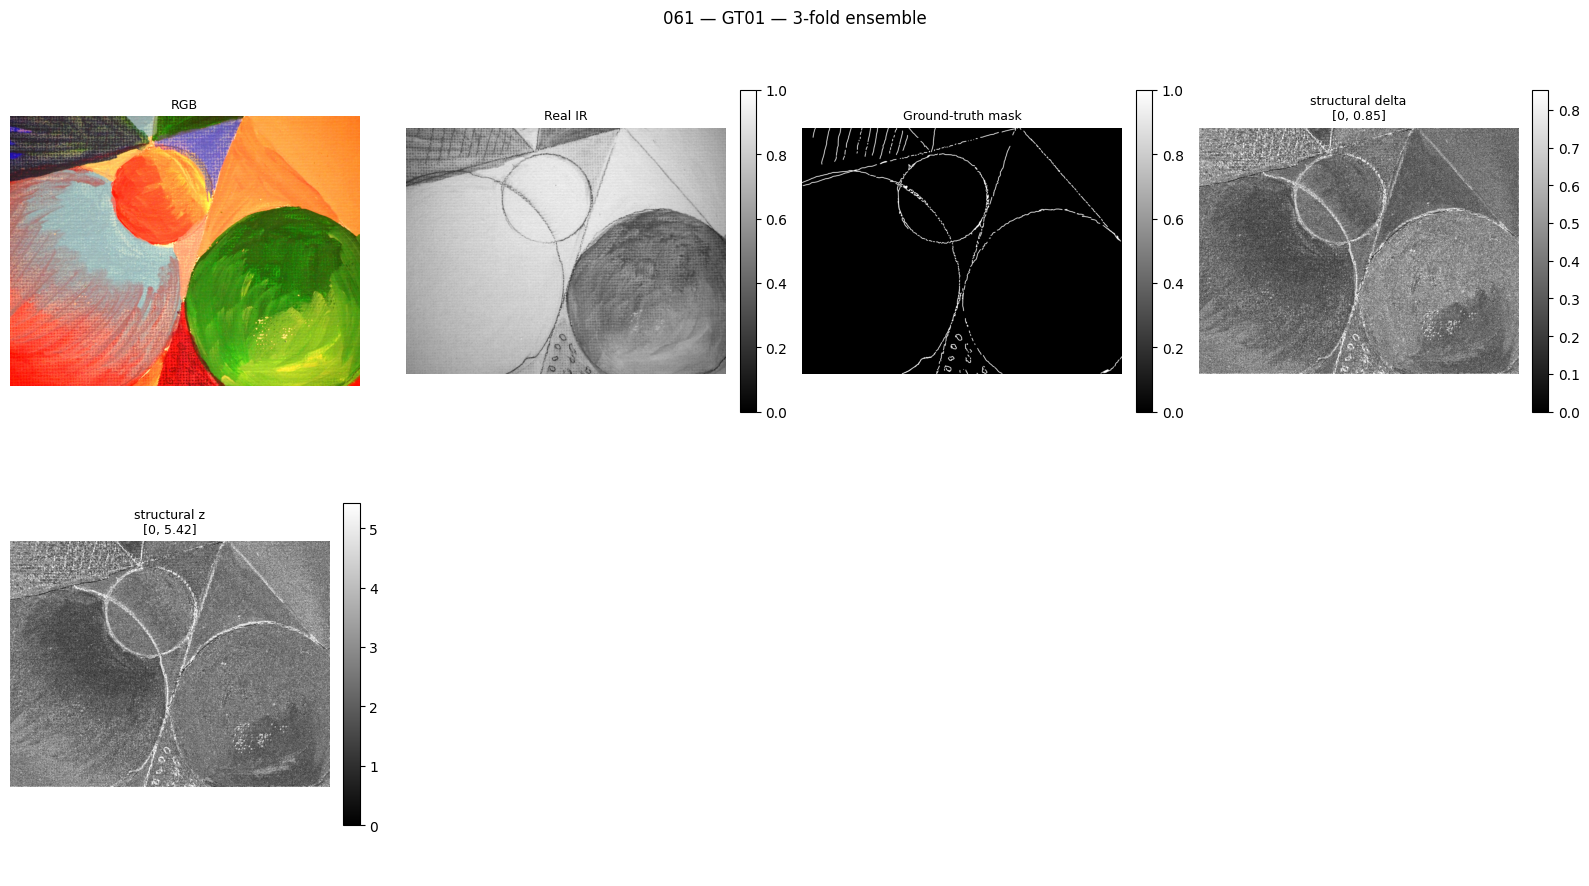

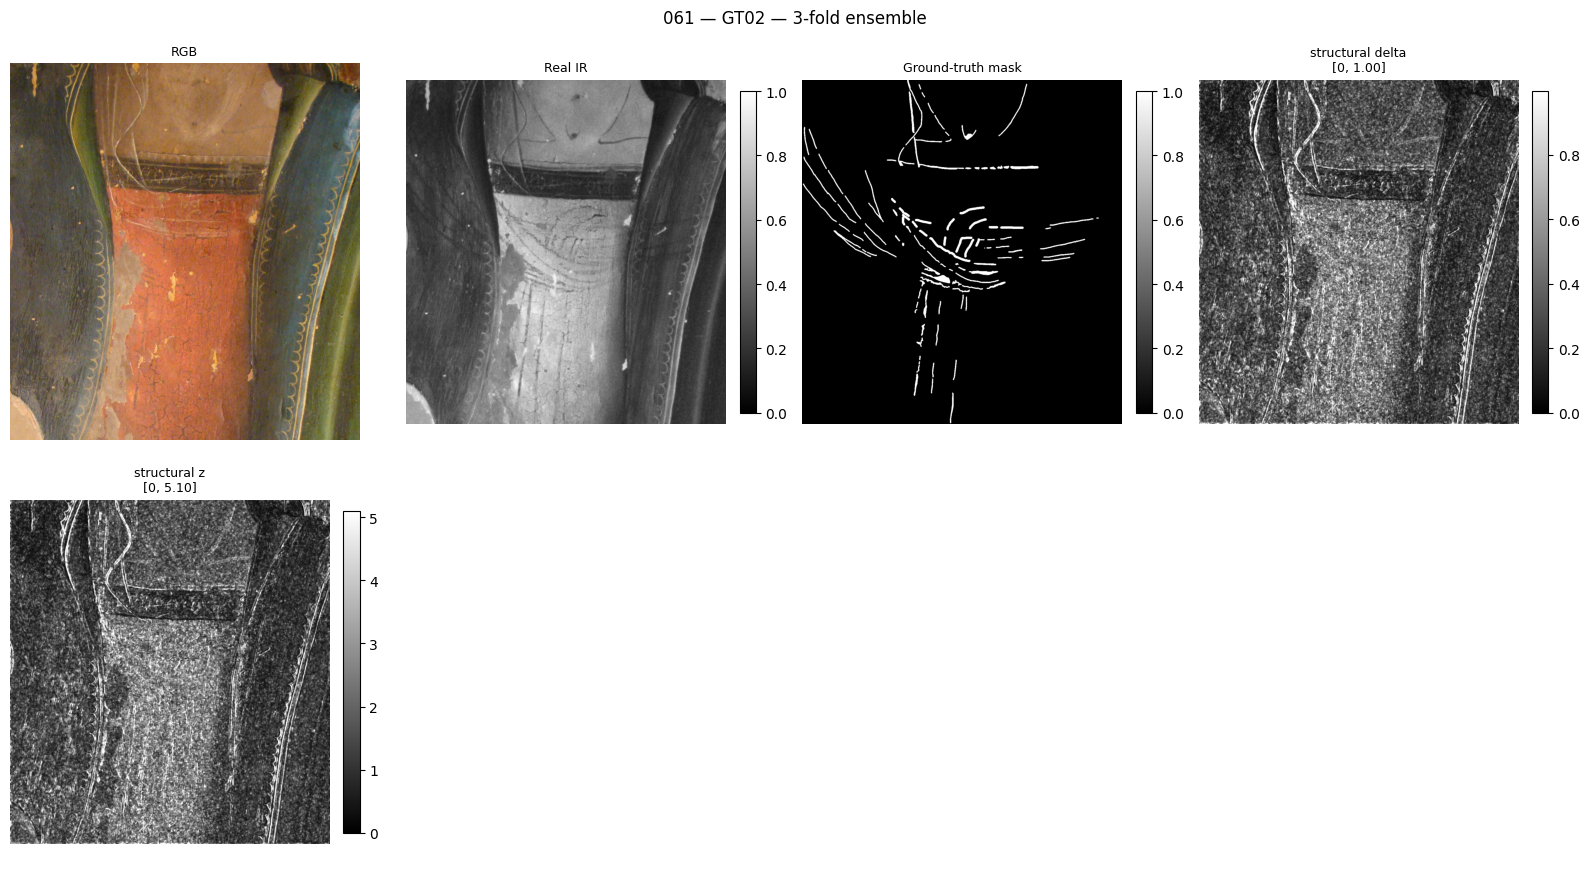

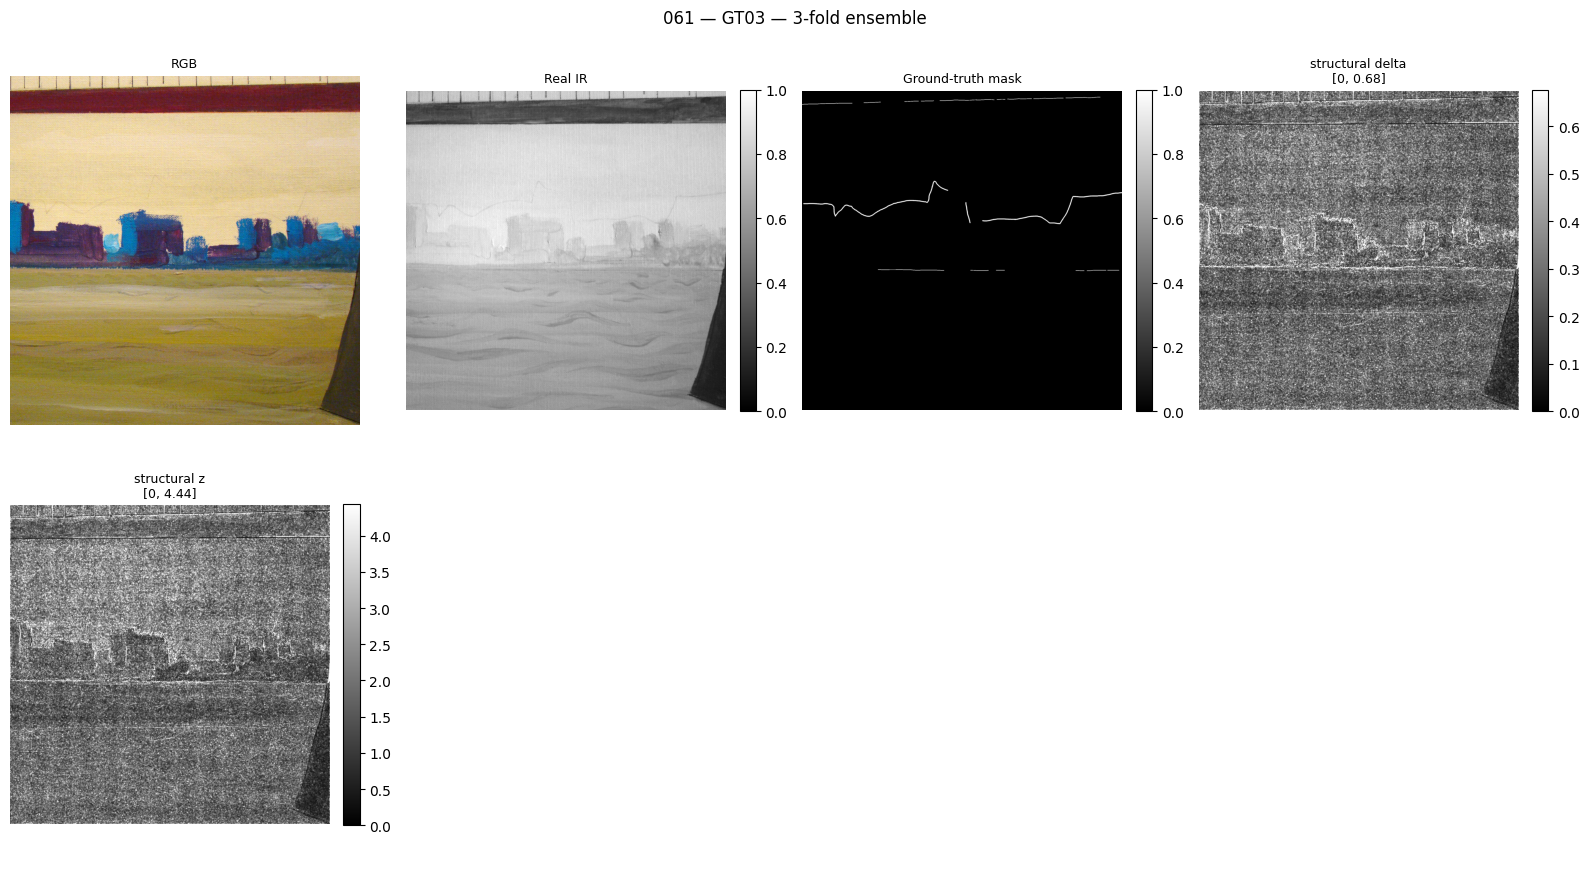

In [8]:
for s in GT_STEMS:
    rgb, ir, mask = gt_data[s]
    mu_e = np.mean([preds[s][f][0] for f in available], axis=0)
    sig_e = np.mean([preds[s][f][1] for f in available], axis=0)
    panels = signals_from(ir, mu_e, sig_e)
    fig = plot_gt_signal_gallery(rgb, ir, mask, panels, title=f"061 — {s} — {len(available)}-fold ensemble")
    plt.show()
    plt.close(fig)

## 6. Conclusion

**All 3 folds trained and evaluated (2026-08-27).** `attention_unet_nll`, k=3, β=0.5,
real artworks grouped by ID (no section leakage), mockups in every train set, GT
paintings external to every fold.

- **Training was stable across folds** — early-stopped at epoch 22 / 38 / 24, best
  `val_loss` −0.3844 / −0.4451 / −0.4424. Fold 0 (held-out `mano`/`mod`/`natmorta2`/
  `q2`/`q3`/`santo`/`sch02`/`sch03`/`volto`) is the hardest split; folds 1–2 agree
  tightly.

- **Held-out pixel spread (§2):** `val_loss` −0.4240 ± 0.0280, MAE 0.103 ± 0.013
  across folds. Small relative spread — the single-split point estimates in
  `030`/`031`/`033` are representative, not lucky.

- **Detection AUROC spread (§3/§4), mean over GT01–03:**
  - `structural delta` = **0.678 ± 0.008** per fold, **0.700** for the 3-fold ensemble.
  - `structural z`     = **0.699 ± 0.008** per fold, **0.719** for the 3-fold ensemble.
  - Std of ~0.008 is far below the gap between signals or between GT paintings — the
    fold-to-fold variance does **not** change any ranking. `structural z` ≥
    `structural delta` on every fold and on the ensemble, consistent with `C4`/`C5`.
  - These match the earlier single-split `attention_unet_nll` numbers (`031`/`C4`:
    `structural delta` ≈ 0.70, `structural z` ≈ 0.71) — cross-validation **confirms**
    the single-split estimate rather than deflating it.

- **Per-GT pattern is unchanged from `C5`:** GT01 strong (0.73–0.82), GT02 moderate
  (0.66–0.69), GT03 weak (0.57–0.69). GT03 stays the hard case regardless of which
  fold predicts it — this is a property of GT03's underdrawing (only visible in real
  IR), not of the train/val split.

- **Ensemble > best single fold** on both signals (0.700 vs 0.686; 0.719 vs 0.710).
  Averaging the fold `μ`s is a free, small, consistent gain — worth reporting as the
  headline configuration.

**Finding #4 verdict: resolved as "the single split was adequate."** Cross-validation
shows the point-estimate metrics used throughout the project carry a fold-to-fold
std of ~0.008 AUROC / ~0.03 loss — small enough that no earlier conclusion changes.
The defensible headline number for the write-up is **`structural z` AUROC
0.70 ± 0.01 (per fold), 0.72 (3-fold ensemble)** for `attention_unet_nll`.
No second model is needed — fold variance is not alarming.

**Write-up:** `evaluation.md` §8 and `fixing.md` §0 updated with the above; #4 marked
resolved.
